# Explainable AI (XAI) Analysis

This notebook applies explainable AI techniques to interpret the machine learning models developed for PCOS prediction.

The analysis focuses on:

- SHAP (SHapley Additive exPlanations)
- LIME (Local Interpretable Model-agnostic Explanations)

These techniques help explain how features influenced model predictions and improve transparency in healthcare-focused AI systems.

In [1]:
# Data handling
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Explainable AI libraries
import shap
from lime.lime_tabular import LimeTabularExplainer

# Saving and loading models
import joblib

c:\Users\c7271492\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load cleaned dataset

df = pd.read_csv("../data/processed/pcos_cleaned.csv")

# Display first rows
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,2,2,0,36,65.0,161.5,24.9,15,74,20,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,3,3,1,33,68.8,165.0,25.3,11,72,18,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,4,4,0,37,65.0,148.0,29.7,13,72,20,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,5,5,0,25,52.0,161.0,20.1,11,72,18,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0


In [3]:
# Define target variable

y = df["PCOS (Y/N)"]

# Define feature variables
X = df.drop("PCOS (Y/N)", axis=1)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Convert object columns to numeric

X_train["II    beta-HCG(mIU/mL)"] = pd.to_numeric(
    X_train["II    beta-HCG(mIU/mL)"],
    errors="coerce"
)

X_test["II    beta-HCG(mIU/mL)"] = pd.to_numeric(
    X_test["II    beta-HCG(mIU/mL)"],
    errors="coerce"
)

X_train["AMH(ng/mL)"] = pd.to_numeric(
    X_train["AMH(ng/mL)"],
    errors="coerce"
)

X_test["AMH(ng/mL)"] = pd.to_numeric(
    X_test["AMH(ng/mL)"],
    errors="coerce"
)

# Fill missing values
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())


# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data prepared successfully.")

Data prepared successfully.


# Final Model Selection

Random Forest was selected as the final model for explainability analysis because it achieved the strongest overall predictive performance during evaluation.

In [4]:
# Train Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


# SHAP Analysis

SHAP (SHapley Additive exPlanations) was used to explain how features influenced the Random Forest model predictions.

SHAP helps identify:
- the most important features
- positive and negative feature influence
- how individual predictions were formed

In [5]:
# Create SHAP explainer

explainer = shap.TreeExplainer(rf_model)

# Generate SHAP values
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values generated successfully.")

SHAP values generated successfully.


# SHAP Feature Importance

The SHAP summary plot shows which features had the greatest influence on the Random Forest model predictions.

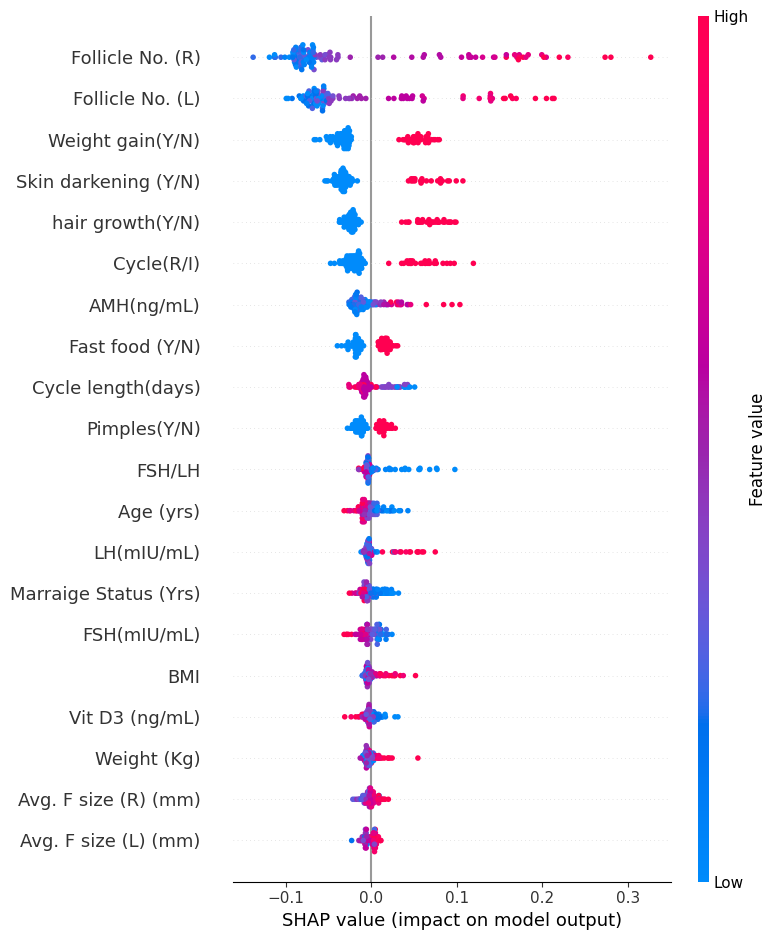

In [6]:
# SHAP summary plot

shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    feature_names=X.columns
)

# SHAP Local Explanation

A SHAP waterfall plot was used to explain how individual features contributed to a single prediction made by the Random Forest model.

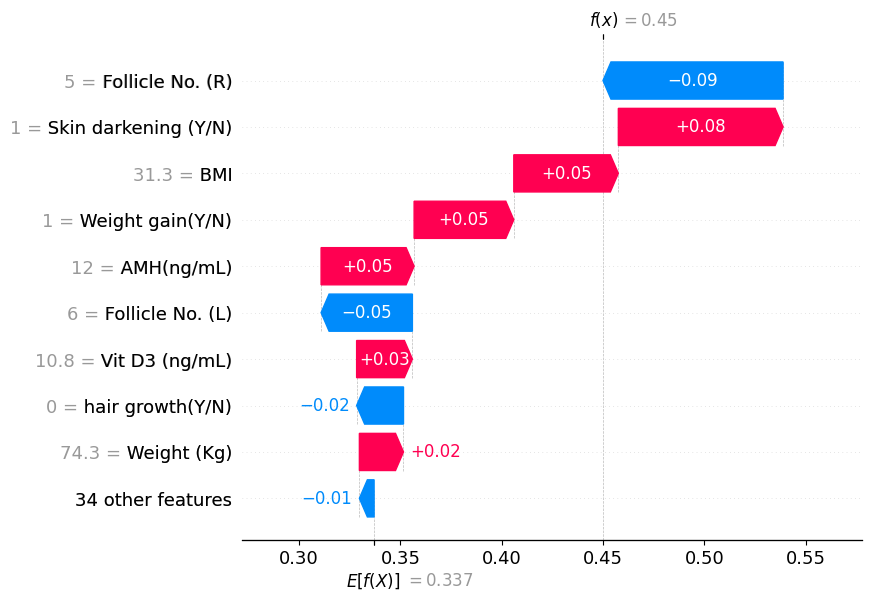

In [7]:
# Generate SHAP waterfall plot for one prediction

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[:, :, 1][0],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[0],
        feature_names=X.columns
    )
)

# LIME Explanation

LIME (Local Interpretable Model-agnostic Explanations) was used to explain individual Random Forest predictions by approximating local model behaviour around a specific prediction.

In [8]:
# Create LIME explainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X.columns.tolist(),
    class_names=["No PCOS", "PCOS"],
    mode="classification"
)

print("LIME explainer created successfully.")

LIME explainer created successfully.


In [9]:
# Explain first test prediction

lime_exp = lime_explainer.explain_instance(
    X_test_scaled[0],
    rf_model.predict_proba,
    num_features=10
)

print("LIME explanation generated successfully.")

LIME explanation generated successfully.


In [10]:
# Display LIME explanation as feature list

lime_exp.as_list()

[('-0.84 < Follicle No. (R) <= -0.17', -0.09599623848002165),
 ('hair growth(Y/N) <= -0.60', -0.0918730707858589),
 ('-0.71 < Skin darkening (Y/N) <= 1.41', 0.09006631320580415),
 ('-0.80 < Weight gain(Y/N) <= 1.25', 0.07388292218420828),
 ('-0.78 < Follicle No. (L) <= -0.07', -0.0711217223210958),
 ('Cycle(R/I) <= -0.63', -0.055959800863487036),
 ('AMH(ng/mL) > 0.23', 0.041624460793998834),
 ('Vit D3 (ng/mL) <= -0.08', 0.022510188364785463),
 ('-0.63 < Cycle length(days) <= 0.05', -0.017069636576632408),
 ('-0.39 < TSH (mIU/L) <= -0.20', -0.013408107625540684)]

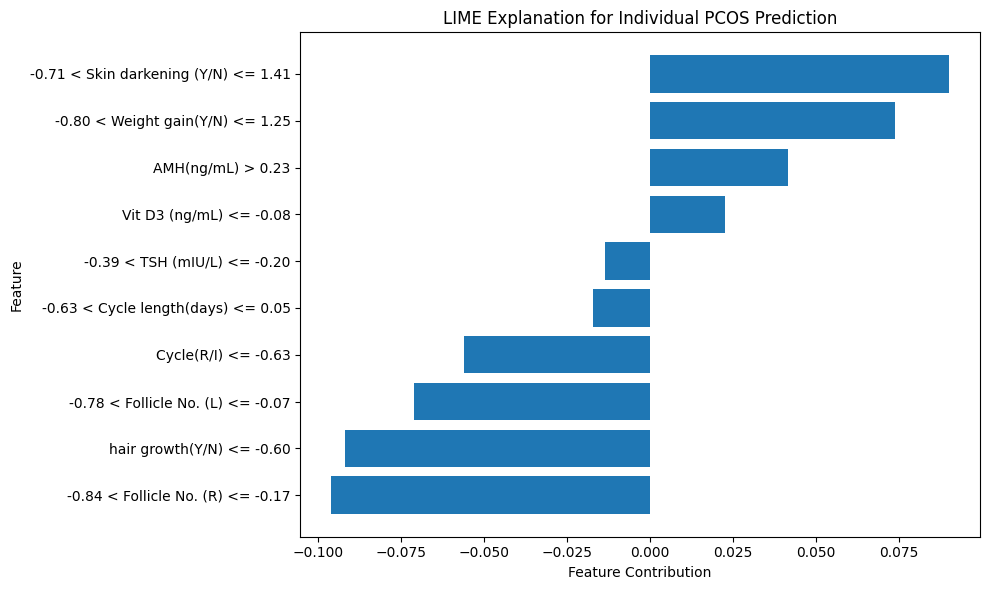

In [11]:

# LIME Bar Chart Visualisation
# 

# Convert explanation into DataFrame
lime_df = pd.DataFrame(
    lime_exp.as_list(),
    columns=["Feature", "Contribution"]
)

# Sort values for cleaner visualisation
lime_df = lime_df.sort_values(
    by="Contribution",
    ascending=True
)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

plt.barh(
    lime_df["Feature"],
    lime_df["Contribution"]
)

# Add labels and title
plt.xlabel("Feature Contribution")
plt.ylabel("Feature")
plt.title("LIME Explanation for Individual PCOS Prediction")

plt.tight_layout()
plt.show()

# XAI Summary

SHAP and LIME were successfully applied to explain Random Forest predictions for PCOS classification.

Both techniques identified clinically relevant features such as follicle count, weight gain, hormonal measurements, and skin-related symptoms as important contributors to model predictions.

The explainability analysis improved transparency by showing how features influenced both global model behaviour and individual patient-level predictions.